# 🏥 Vision Transformer Small Baseline - ACL Classifier

Pipeline para entrenar modelos Vision Transformer Small independientes por plano anatómico.
**Versión compacta: ~22M parámetros vs 27.8M del ConvNeXt o 86M del ViT-Base.**

**Características:**
- Usa ViT Small pre-entrenado desde HuggingFace: `WinKawaks/vit-small-patch16-224`
- Pesos pre-entrenados: ImageNet-1K
- Feature dimension: 768D (mismo que ConvNeXt/Swin/ViT-Base)
- Punto medio ideal entre rapidez (vs ViT-Base) y capacidad (vs ViT-Tiny)
- Misma configuración de preprocesado, augmentation, loss y evaluación que otros baselines
- Checkpoints guardados en `checkpoints/vit_small_baseline/`
- Esperado: AUC similar a otros baselines con balance eficiencia-performance

## 1️⃣ Imports y Configuración

In [6]:
# Imports estándar
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1,2,3'  # Oculta GPU 0 de PyTorch

import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas y evaluación
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, confusion_matrix

# Módulos locales
import sys
sys.path.insert(0, '../../../src')

from gpu_config import device, VIT_GPU_IDS, CNN_GPU_ID
from models import ViTSmallMultiSliceClassifier
from data_loader import OptimizedMRNetDataset, get_train_transform, get_val_test_transform
from training_utils import train_model

print("✓ Todos los módulos importados exitosamente")

✓ Todos los módulos importados exitosamente


## 2️⃣ Configuración Global (para ViT Small)

In [9]:
# ==========================================
# RUTAS Y DIRECTORIOS - ROBUSTAS
# ==========================================
# Detectar ubicación del notebook y construir rutas absolutas
import os
notebook_dir = Path('/home/palodo2/tfg/acl_classifier/models/vit_small')
project_root = notebook_dir.parent.parent  # /home/palodo2/tfg/acl_classifier

DATA_PATH = project_root / 'data'
CHECKPOINT_DIR = project_root / 'checkpoints' / 'vit_small_baseline'
SLICE_INDICES_DIR = DATA_PATH / 'slice_indices_final'

# Verificar que existen
print(f"📁 Verificando rutas:")
print(f"  Project root: {project_root}")
print(f"  Data path exists: {DATA_PATH.exists()} → {DATA_PATH}")
print(f"  Data/train exists: {(DATA_PATH / 'train').exists()}")
print(f"  Data/val exists: {(DATA_PATH / 'val').exists()}")
print(f"  Data/test exists: {(DATA_PATH / 'test').exists()}")
print(f"  train-acl.csv exists: {(DATA_PATH / 'train-acl.csv').exists()}")
print(f"  val-acl.csv exists: {(DATA_PATH / 'val-acl.csv').exists()}")
print(f"  test-acl.csv exists: {(DATA_PATH / 'test-acl.csv').exists()}\n")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SLICE_INDICES_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# CONFIGURACIÓN DE POOLING Y ESTRATEGIA
# ==========================================
PLANE_CONFIG = {
    'sagittal': {
        'num_slices': 5,
        'strategy': 'cnn_based',
        'pooling_mode': 'attention',
        'description': 'CNN Selector V3'
    },
    'coronal': {
        'num_slices': 10,
        'strategy': 'cnn_based',
        'pooling_mode': 'max',
        'description': 'CNN Selector Coronal'
    },
    'axial': {
        'num_slices': 10,
        'strategy': 'center_consecutive',
        'pooling_mode': 'attention',
        'description': '10 slices centrales'
    }
}

PLANES = ['sagittal', 'coronal', 'axial']
VIT_MODEL_NAME = "WinKawaks/vit-small-patch16-224"
IMAGE_SIZE = 224
NUM_CLASSES = 1
BATCH_SIZE = 64
NUM_WORKERS = 8
SEED = 42
NUM_EPOCHS = 150

# ==========================================
# CONFIGURACIÓN DE AUGMENTATION POR PLANO
# ==========================================
AUGMENTATION_MODE_PER_PLANE = {
    'sagittal': 'conservative',
    'coronal': 'moderate',
    'axial': 'aggressive'
}

# ==========================================
# CONFIGURACIÓN ESPECÍFICA POR PLANO (ViT Small)
# ==========================================
PLANE_SPECIFIC_CONFIG = {
    'sagittal': {
        'learning_rate': 1.2e-4,
        'weight_decay': 1e-3,
        'dropout_input': 0.2,
        'dropout_dense': 0.15,
        'use_scheduler': True,
        'use_grad_clip': False,
        'early_stopping_patience': 25,
        'label_smoothing': 0.025,
        'warmup_epochs': 5,
        'status': '🚀 ViT Small - Regularización Moderada (WD=1e-3, Dropout=0.2/0.15)'
    },
    'coronal': {
        'learning_rate': 1.2e-4,
        'weight_decay': 1e-3,
        'dropout_input': 0.25,
        'dropout_dense': 0.15,
        'use_scheduler': True,
        'use_grad_clip': True,
        'early_stopping_patience': 15,
        'label_smoothing': 0.025,
        'warmup_epochs': 5,
        'status': '✅ Regularización Moderada (WD=1e-3, Dropout=0.25/0.15)'
    },
    'axial': {
        'learning_rate': 1.2e-4,
        'weight_decay': 5e-4,
        'dropout_input': 0.25,
        'dropout_dense': 0.15,
        'use_scheduler': True,
        'use_grad_clip': True,
        'early_stopping_patience': 15,
        'label_smoothing': 0.05,
        'warmup_epochs': 5,
        'status': '🎯 Regularización Moderada: weight_decay=5e-4, dropout=0.25/0.15, smoothing=0.05'
    }
}

# ==========================================
# CONFIGURACIÓN DE WANDB
# ==========================================
USE_WANDB = False  # Cambiar a True para usar Weights & Biases
WANDB_PROJECT = "acl-classifier-vit-small"
WANDB_ENTITY = "tfg-acl"

# Set random seeds
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"\n{'='*100}")
print(f"✅ CONFIGURACIÓN CARGADA (ViT Small - Baseline)")
print(f"{'='*100}")
print(f"\n📊 Configuración global:")
print(f"  Data path: {DATA_PATH}")
print(f"  Checkpoint dir: {CHECKPOINT_DIR}")
print(f"  Slice indices dir: {SLICE_INDICES_DIR}")
print(f"  Num epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Model: ViT Small ({VIT_MODEL_NAME})")
print(f"  Wandb enabled: {USE_WANDB}")

print(f"\n🎯 Configuración por plano:")
for plane in PLANES:
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    pool_cfg = PLANE_CONFIG[plane]
    print(f"\n  {plane.upper()}:")
    print(f"    • Slices: {pool_cfg['num_slices']} ({pool_cfg['strategy']})")
    print(f"    • Pooling: {pool_cfg['pooling_mode']}")
    print(f"    • LR: {cfg['learning_rate']:.2e}")
    print(f"    • Weight decay: {cfg['weight_decay']:.2e}")
    print(f"    • Dropout: {cfg['dropout_input']:.2f}/{cfg['dropout_dense']:.2f}")
    print(f"    • Augmentation: {AUGMENTATION_MODE_PER_PLANE[plane]}")
    print(f"    • Warmup: {cfg['warmup_epochs']} epochs")
    print(f"    • Patience: {cfg['early_stopping_patience']}")
    print(f"    • Status: {cfg['status']}")

print(f"\n{'='*100}\n")

📁 Verificando rutas:
  Project root: /home/palodo2/tfg/acl_classifier
  Data path exists: True → /home/palodo2/tfg/acl_classifier/data
  Data/train exists: True
  Data/val exists: True
  Data/test exists: True
  train-acl.csv exists: True
  val-acl.csv exists: True
  test-acl.csv exists: True


✅ CONFIGURACIÓN CARGADA (ViT Small - Baseline)

📊 Configuración global:
  Data path: /home/palodo2/tfg/acl_classifier/data
  Checkpoint dir: /home/palodo2/tfg/acl_classifier/checkpoints/vit_small_baseline
  Slice indices dir: /home/palodo2/tfg/acl_classifier/data/slice_indices_final
  Num epochs: 150
  Batch size: 64
  Model: ViT Small (WinKawaks/vit-small-patch16-224)
  Wandb enabled: False

🎯 Configuración por plano:

  SAGITTAL:
    • Slices: 5 (cnn_based)
    • Pooling: attention
    • LR: 1.20e-04
    • Weight decay: 1.00e-03
    • Dropout: 0.20/0.15
    • Augmentation: conservative
    • Warmup: 5 epochs
    • Patience: 25
    • Status: 🚀 ViT Small - Regularización Moderada (WD=1e-3, Dropo

## 3️⃣ Entrenar SAGITTAL

In [10]:
train_sagittal = True  # Cambiar a True para entrenar

if train_sagittal:
    plane = 'sagittal'
    print(f"\n{'='*80}")
    print(f"🔄 ENTRENANDO VIT SMALL: {plane.upper()}")
    print(f"{'='*80}\n")

    # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_cfg = PLANE_CONFIG[plane]
    plane_pooling_mode = plane_cfg.get('pooling_mode', 'attention')

    # Crear datasets
    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    # Crear DataLoaders
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f"✓ DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

    # Crear modelo ViT Small
    model = ViTSmallMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        model_name=VIT_MODEL_NAME
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f"✓ Modelo ViT Small en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

    # Entrenar
    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', True),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=1.0,
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 5)
    )

    print(f"\n{'='*80}")
    print(f"✅ SAGITTAL COMPLETADO (ViT Small)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


🔄 ENTRENANDO VIT SMALL: SAGITTAL

✓ Dataset cargado: 875 casos
  Plane: sagittal
  Augmentation: conservative
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/train_sagittal_indices.json
✓ Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/val_sagittal_indices.json
✓ DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo ViT Small en GPUs: [0, 1, 2]

  Config: 🚀 ViT Small - Regularización Moderada (WD=1e-3, Dropout=0.2/0.15)


ENTRENANDO MODELO: SAGITTAL
LR=0.00012, WD=0.001, Scheduler=True, GradClip=False
Dropout: Input=0.2, Dense=0.15
Augmentation: conservative

📊 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)

Epoch 1/150 (LR=2.40e-05): Train: Loss=1.1155, AUC=0.6017 | Val: Loss=0.9805, AUC=0.7462, F1=0.4516 ✓ Best AUC!
Epoch 2/150 (LR=4.80e-05): Train: Loss=0.9788, AUC=0.7376 | Val: Loss=0.9236, AUC=0.7767, F1=0.5143 ✓ Best AUC!
Epoch 3/150 (LR=7.20e-05): Train: Loss=0.9535, AUC=0.7676 | Val: Loss=0.8672, AUC=0.8032, F1=0.5679 ✓ Best AUC!
Epoch 4/150 (LR=9.60e-05): Train: Loss=0.9024, AUC=0.8021 | Val: Loss=0.8162, AUC=0.8363, F1=0.5977 ✓ Best AUC!
Epoch 5/150 (LR=1.20e-04): Train: Loss=0.7853, AUC=0.8631 | Val: Loss=0.7839, AUC=0.8573, F1=0.6024 ✓ Best AUC!
Epoch 6/150 (LR=1.20e-04): Train: Loss=0.6493, AUC=0.9140 | Val: Loss=0.8642, AUC=0.8642, F1=0.5517 ✓ Best AUC!



📊 RESULTADOS DE LA MEJOR ÉPOCA: 20
✓ Val AUC:        0.9483
✓ Val F1:         0.7750
✓ Val Loss:       0.5881
✓ Train Loss:     0.2714
✓ Learning Rate:  1.17e-04



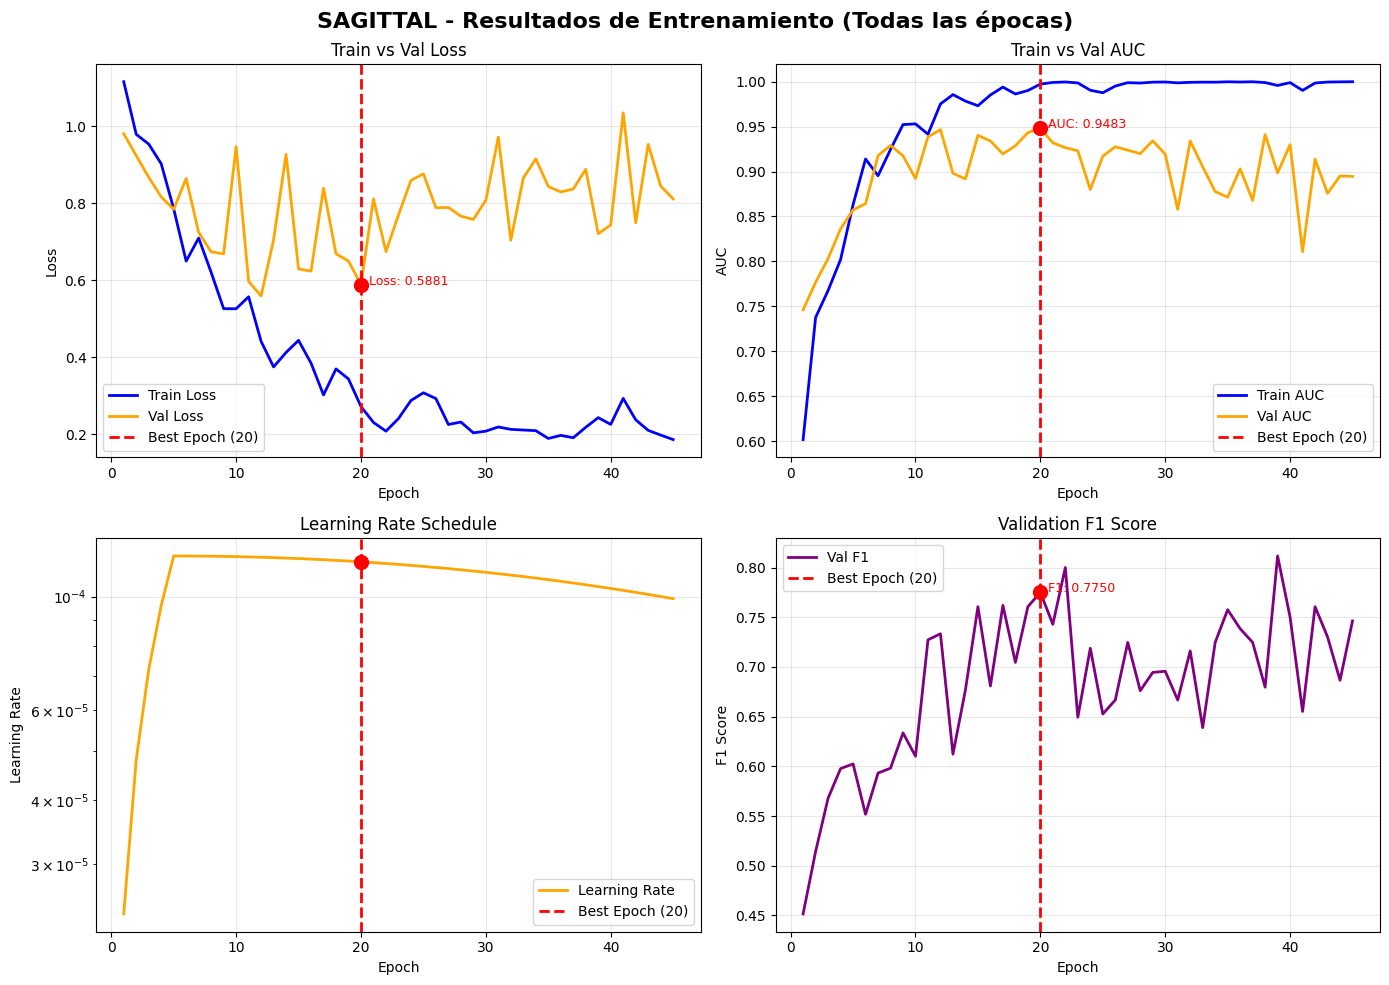

In [11]:
# ==========================================
# VISUALIZACIÓN DE RESULTADOS - SAGITTAL
# ==========================================
best_epoch_idx = np.argmax(history['val_auc'])
best_epoch = best_epoch_idx + 1

best_auc_epoch = history['val_auc'][best_epoch_idx]
best_f1_epoch = history['val_f1'][best_epoch_idx]
best_loss_epoch = history['val_loss_objective'][best_epoch_idx]
best_train_loss_epoch = history['train_loss'][best_epoch_idx]
best_lr_epoch = history['learning_rates'][best_epoch_idx]

print(f"\n{'='*80}")
print(f"📊 RESULTADOS DE LA MEJOR ÉPOCA: {best_epoch}")
print(f"{'='*80}")
print(f"✓ Val AUC:        {best_auc_epoch:.4f}")
print(f"✓ Val F1:         {best_f1_epoch:.4f}")
print(f"✓ Val Loss:       {best_loss_epoch:.4f}")
print(f"✓ Train Loss:     {best_train_loss_epoch:.4f}")
print(f"✓ Learning Rate:  {best_lr_epoch:.2e}")
print(f"{'='*80}\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados de Entrenamiento (Todas las épocas)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss
ax = axes[0, 0]
ax.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_loss_objective']) + 1), history['val_loss_objective'], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss_epoch, f'  Loss: {best_loss_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC
ax = axes[0, 1]
ax.plot(range(1, len(history['train_auc']) + 1), history['train_auc'], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_auc']) + 1), history['val_auc'], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_auc_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc_epoch, f'  AUC: {best_auc_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[1, 0]
ax.plot(range(1, len(history['learning_rates']) + 1), history['learning_rates'], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr_epoch], color='red', s=100, zorder=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score
ax = axes[1, 1]
ax.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1_epoch, f'  F1: {best_f1_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4️⃣ Entrenar CORONAL

In [12]:
train_coronal = True  # Cambiar a True para entrenar

if train_coronal:
    plane = 'coronal'
    print(f"\n{'='*80}")
    print(f"🔄 ENTRENANDO VIT SMALL: {plane.upper()}")
    print(f"{'='*80}\n")

    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_cfg = PLANE_CONFIG[plane]
    plane_pooling_mode = plane_cfg.get('pooling_mode', 'attention')

    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f"✓ DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

    model = ViTSmallMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        model_name=VIT_MODEL_NAME
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f"✓ Modelo ViT Small en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', True),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=1.0,
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 5)
    )

    print(f"\n{'='*80}")
    print(f"✅ CORONAL COMPLETADO (ViT Small)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


🔄 ENTRENANDO VIT SMALL: CORONAL

✓ Dataset cargado: 875 casos
  Plane: coronal
  Augmentation: moderate
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/train_coronal_indices.json
✓ Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/val_coronal_indices.json
✓ DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)



Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo ViT Small en GPUs: [0, 1, 2]

  Config: ✅ Regularización Moderada (WD=1e-3, Dropout=0.25/0.15)


ENTRENANDO MODELO: CORONAL
LR=0.00012, WD=0.001, Scheduler=True, GradClip=True
Dropout: Input=0.25, Dense=0.15
Augmentation: moderate

📊 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)

Epoch 1/150 (LR=2.40e-05): Train: Loss=1.2119, AUC=0.5010 | Val: Loss=1.0611, AUC=0.5736, F1=0.2991 ✓ Best AUC!
Epoch 2/150 (LR=4.80e-05): Train: Loss=1.1184, AUC=0.5789 | Val: Loss=1.0424, AUC=0.6561, F1=0.3758 ✓ Best AUC!
Epoch 3/150 (LR=7.20e-05): Train: Loss=1.0802, AUC=0.6316 | Val: Loss=1.0454, AUC=0.6886, F1=0.3265 ✓ Best AUC!
Epoch 4/150 (LR=9.60e-05): Train: Loss=1.0086, AUC=0.7012 | Val: Loss=1.0795, AUC=0.7125, F1=0.4151 ✓ Best AUC!
Epoch 5/150 (LR=1.20e-04): Train: Loss=1.1053, AUC=0.6553 | Val: Loss=1.0390, AUC=0.6979, F1=0.3388
Epoch 6/150 (LR=1.20e-04): Train: Loss=0.9255, AUC=0.7793 | Val: Loss=0.9032, AUC=0.7787, F1=0.4884 ✓ Best AUC!
Epoch 7/150 (LR=1.20e-04): T


📊 RESULTADOS DE LA MEJOR ÉPOCA: 23
✓ Val AUC:        0.8876
✓ Val F1:         0.2727
✓ Val Loss:       1.7218
✓ Train Loss:     0.4031
✓ Learning Rate:  1.16e-04



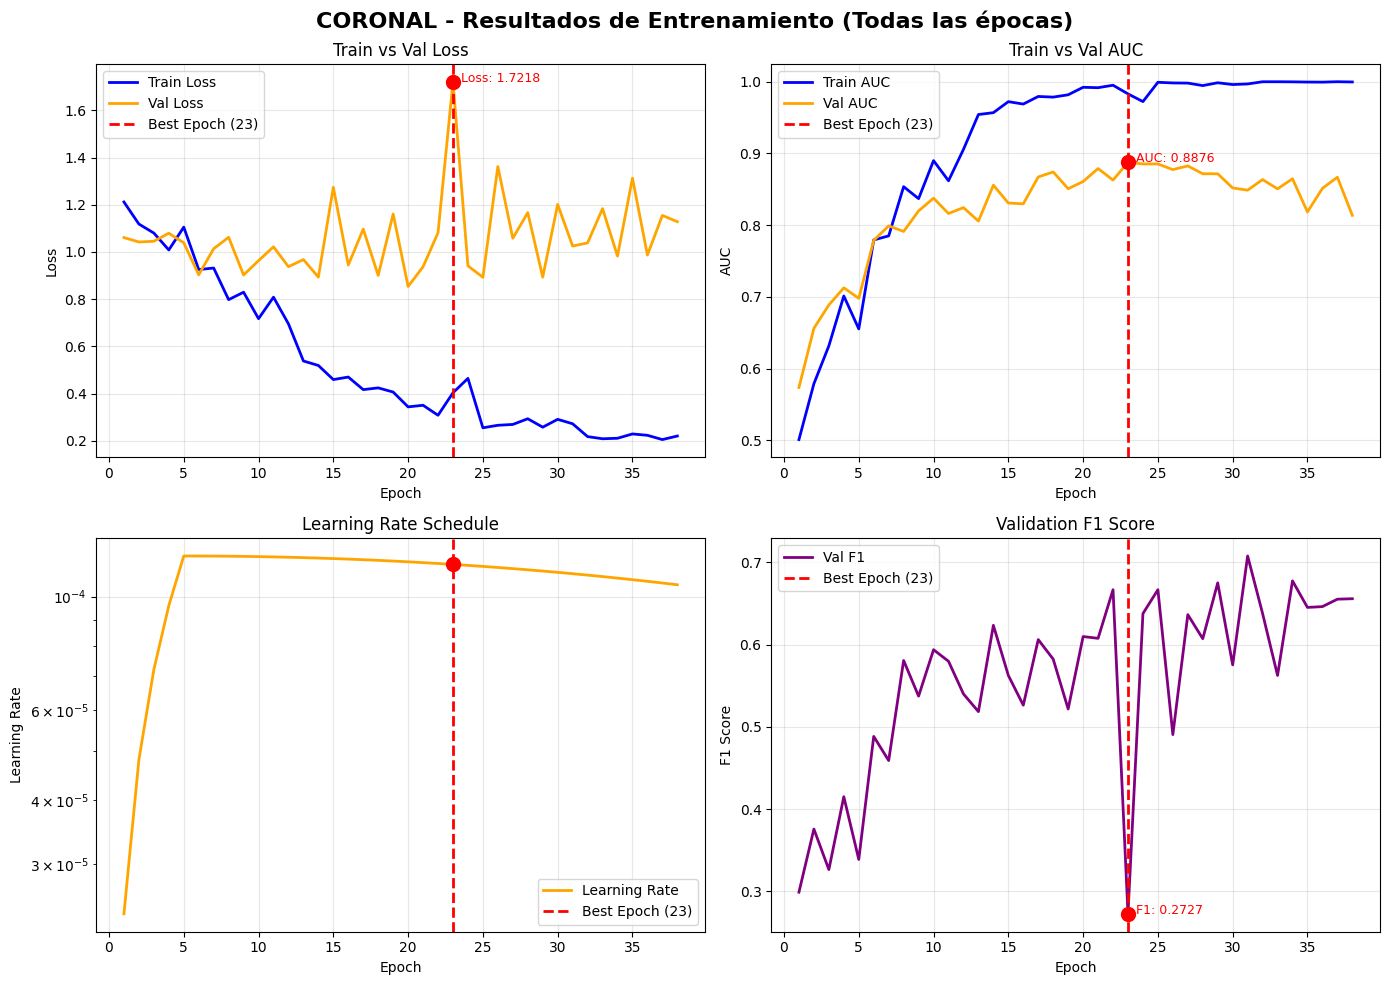

In [13]:
# ==========================================
# VISUALIZACIÓN DE RESULTADOS - CORONAL
# ==========================================
best_epoch_idx = np.argmax(history['val_auc'])
best_epoch = best_epoch_idx + 1

best_auc_epoch = history['val_auc'][best_epoch_idx]
best_f1_epoch = history['val_f1'][best_epoch_idx]
best_loss_epoch = history['val_loss_objective'][best_epoch_idx]
best_train_loss_epoch = history['train_loss'][best_epoch_idx]
best_lr_epoch = history['learning_rates'][best_epoch_idx]

print(f"\n{'='*80}")
print(f"📊 RESULTADOS DE LA MEJOR ÉPOCA: {best_epoch}")
print(f"{'='*80}")
print(f"✓ Val AUC:        {best_auc_epoch:.4f}")
print(f"✓ Val F1:         {best_f1_epoch:.4f}")
print(f"✓ Val Loss:       {best_loss_epoch:.4f}")
print(f"✓ Train Loss:     {best_train_loss_epoch:.4f}")
print(f"✓ Learning Rate:  {best_lr_epoch:.2e}")
print(f"{'='*80}\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados de Entrenamiento (Todas las épocas)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss
ax = axes[0, 0]
ax.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_loss_objective']) + 1), history['val_loss_objective'], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss_epoch, f'  Loss: {best_loss_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC
ax = axes[0, 1]
ax.plot(range(1, len(history['train_auc']) + 1), history['train_auc'], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_auc']) + 1), history['val_auc'], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_auc_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc_epoch, f'  AUC: {best_auc_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[1, 0]
ax.plot(range(1, len(history['learning_rates']) + 1), history['learning_rates'], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr_epoch], color='red', s=100, zorder=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score
ax = axes[1, 1]
ax.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1_epoch, f'  F1: {best_f1_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5️⃣ Entrenar AXIAL

In [14]:
train_axial = True  # Cambiar a True para entrenar

if train_axial:
    plane = 'axial'
    print(f"\n{'='*80}")
    print(f"🔄 ENTRENANDO VIT SMALL: {plane.upper()}")
    print(f"{'='*80}\n")

    cfg = PLANE_SPECIFIC_CONFIG[plane]
    aug_mode = AUGMENTATION_MODE_PER_PLANE[plane]
    plane_cfg = PLANE_CONFIG[plane]
    plane_pooling_mode = plane_cfg.get('pooling_mode', 'attention')

    train_indices_path = SLICE_INDICES_DIR / f"train_{plane}_indices.json"
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"

    train_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'train-acl.csv',
        data_root=DATA_PATH / 'train',
        plane=plane,
        indices_cache_path=train_indices_path,
        augmentation_mode=aug_mode
    )

    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )

    print(f"✓ DataLoaders creados:")
    print(f"  Train: {len(train_loader)} batches ({len(train_dataset)} casos)")
    print(f"  Val: {len(val_loader)} batches ({len(val_dataset)} casos)\n")

    model = ViTSmallMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        pooling_mode=plane_pooling_mode,
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        model_name=VIT_MODEL_NAME
    )

    model = nn.DataParallel(model, device_ids=VIT_GPU_IDS)
    model = model.to(device)

    print(f"✓ Modelo ViT Small en GPUs: {VIT_GPU_IDS}\n")
    print(f"  Config: {cfg['status']}\n")

    history, best_auc, best_f1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        device=device,
        save_dir=CHECKPOINT_DIR,
        plane_name=plane,
        learning_rate=cfg['learning_rate'],
        weight_decay=cfg['weight_decay'],
        label_smoothing=cfg.get('label_smoothing', 0.05),
        use_scheduler=cfg.get('use_scheduler', True),
        use_grad_clip=cfg.get('use_grad_clip', False),
        grad_clip_norm=1.0,
        early_stopping_patience=cfg.get('early_stopping_patience', 15),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        augmentation_mode=aug_mode,
        use_wandb=USE_WANDB,
        warmup_epochs=cfg.get('warmup_epochs', 5)
    )

    print(f"\n{'='*80}")
    print(f"✅ AXIAL COMPLETADO (ViT Small)")
    print(f"   Best AUC: {best_auc:.4f}")
    print(f"   Best F1: {best_f1:.4f}")
    print(f"{'='*80}\n")


🔄 ENTRENANDO VIT SMALL: AXIAL

✓ Dataset cargado: 875 casos
  Plane: axial
  Augmentation: aggressive
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/train_axial_indices.json
✓ Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/val_axial_indices.json
✓ DataLoaders creados:
  Train: 14 batches (875 casos)
  Val: 3 batches (188 casos)



Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Modelo ViT Small en GPUs: [0, 1, 2]

  Config: 🎯 Regularización Moderada: weight_decay=5e-4, dropout=0.25/0.15, smoothing=0.05


ENTRENANDO MODELO: AXIAL
LR=0.00012, WD=0.0005, Scheduler=True, GradClip=True
Dropout: Input=0.25, Dense=0.15
Augmentation: aggressive

📊 Class imbalance (pos_weight): 3.7814
   (Ratio negatives:positives)

Epoch 1/150 (LR=2.40e-05): Train: Loss=1.0769, AUC=0.6508 | Val: Loss=1.1678, AUC=0.7138, F1=0.3077 ✓ Best AUC!
Epoch 2/150 (LR=4.80e-05): Train: Loss=0.9929, AUC=0.7542 | Val: Loss=0.9787, AUC=0.7577, F1=0.5000 ✓ Best AUC!
Epoch 3/150 (LR=7.20e-05): Train: Loss=0.9670, AUC=0.7883 | Val: Loss=0.9558, AUC=0.7738, F1=0.5053 ✓ Best AUC!
Epoch 4/150 (LR=9.60e-05): Train: Loss=0.8899, AUC=0.8268 | Val: Loss=1.0081, AUC=0.7438, F1=0.5063
Epoch 5/150 (LR=1.20e-04): Train: Loss=0.8631, AUC=0.8451 | Val: Loss=1.0893, AUC=0.7851, F1=0.4025 ✓ Best AUC!
Epoch 6/150 (LR=1.20e-04): Train: Loss=0.8596, AUC=0.8490 | Val: Loss=0.9330, AUC=0.8023, F1=0.5974 ✓ Best AUC!
Ep


📊 RESULTADOS DE LA MEJOR ÉPOCA: 19
✓ Val AUC:        0.9486
✓ Val F1:         0.7671
✓ Val Loss:       0.6902
✓ Train Loss:     0.6157
✓ Learning Rate:  1.17e-04



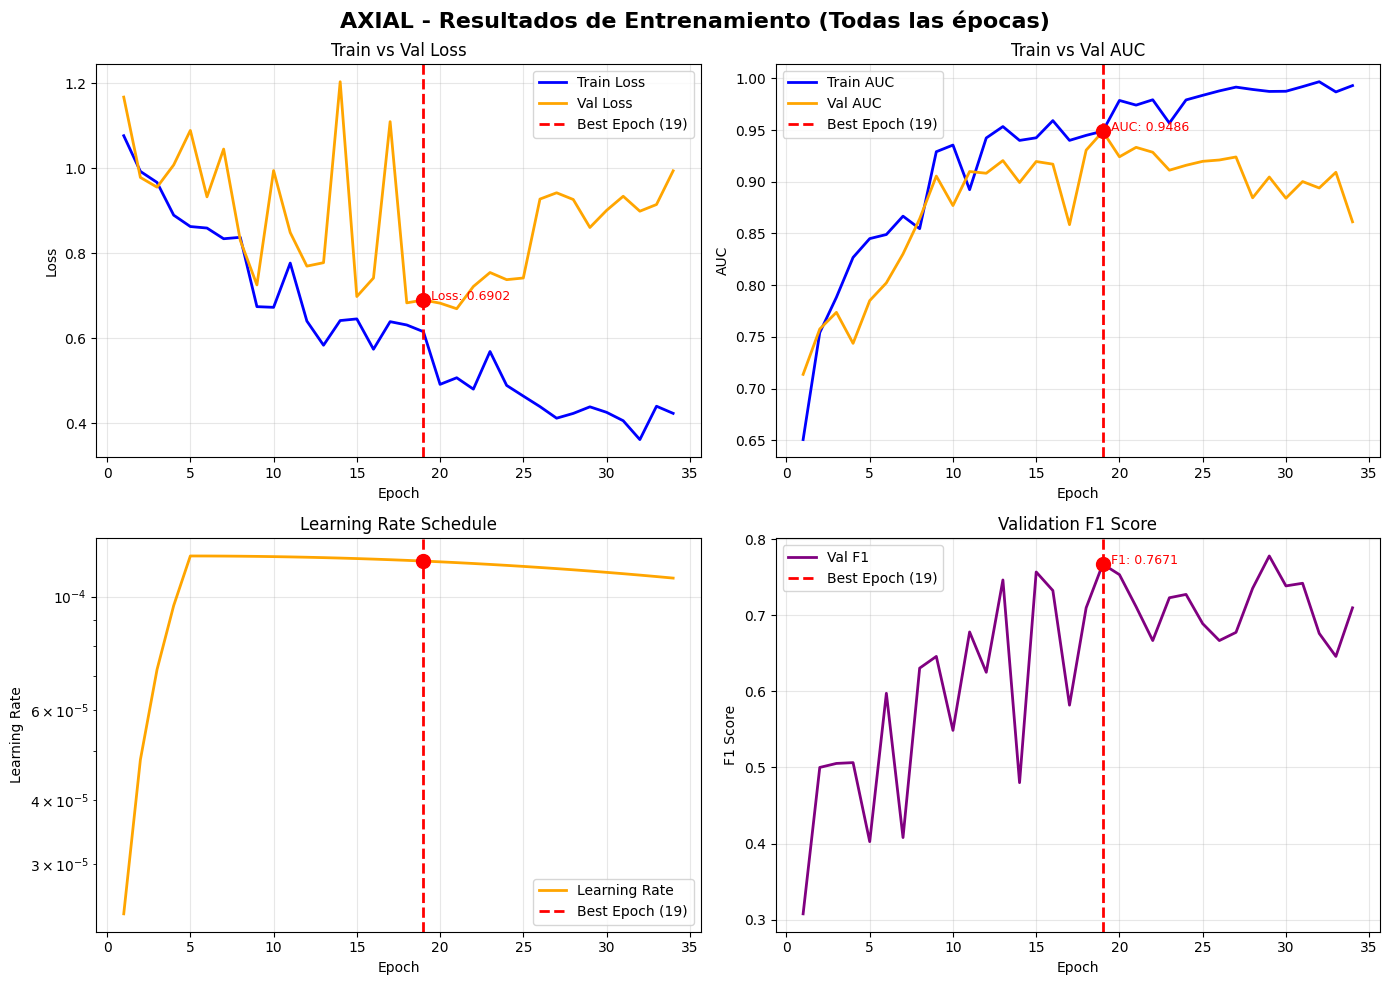

In [15]:
# ==========================================
# VISUALIZACIÓN DE RESULTADOS - AXIAL
# ==========================================
best_epoch_idx = np.argmax(history['val_auc'])
best_epoch = best_epoch_idx + 1

best_auc_epoch = history['val_auc'][best_epoch_idx]
best_f1_epoch = history['val_f1'][best_epoch_idx]
best_loss_epoch = history['val_loss_objective'][best_epoch_idx]
best_train_loss_epoch = history['train_loss'][best_epoch_idx]
best_lr_epoch = history['learning_rates'][best_epoch_idx]

print(f"\n{'='*80}")
print(f"📊 RESULTADOS DE LA MEJOR ÉPOCA: {best_epoch}")
print(f"{'='*80}")
print(f"✓ Val AUC:        {best_auc_epoch:.4f}")
print(f"✓ Val F1:         {best_f1_epoch:.4f}")
print(f"✓ Val Loss:       {best_loss_epoch:.4f}")
print(f"✓ Train Loss:     {best_train_loss_epoch:.4f}")
print(f"✓ Learning Rate:  {best_lr_epoch:.2e}")
print(f"{'='*80}\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{plane.upper()} - Resultados de Entrenamiento (Todas las épocas)', fontsize=16, fontweight='bold')

# 1. Train vs Val Loss
ax = axes[0, 0]
ax.plot(range(1, len(history['train_loss']) + 1), history['train_loss'], label='Train Loss', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_loss_objective']) + 1), history['val_loss_objective'], label='Val Loss', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_loss_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_loss_epoch, f'  Loss: {best_loss_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Val Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. AUC
ax = axes[0, 1]
ax.plot(range(1, len(history['train_auc']) + 1), history['train_auc'], label='Train AUC', linewidth=2, color='blue')
ax.plot(range(1, len(history['val_auc']) + 1), history['val_auc'], label='Val AUC', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_auc_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_auc_epoch, f'  AUC: {best_auc_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Train vs Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Learning Rate
ax = axes[1, 0]
ax.plot(range(1, len(history['learning_rates']) + 1), history['learning_rates'], label='Learning Rate', linewidth=2, color='orange')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_lr_epoch], color='red', s=100, zorder=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. F1 Score
ax = axes[1, 1]
ax.plot(range(1, len(history['val_f1']) + 1), history['val_f1'], label='Val F1', linewidth=2, color='purple')
ax.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_f1_epoch], color='red', s=100, zorder=5)
ax.text(best_epoch, best_f1_epoch, f'  F1: {best_f1_epoch:.4f}', fontsize=9, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6️⃣ Cargar Modelos para Ensamble

In [16]:
# Cargar los 3 modelos entrenados
print(f"\n{'='*80}")
print(f"🔄 CARGANDO MODELOS ENTRENADOS PARA ENSAMBLE")
print(f"{'='*80}\n")

models_ensemble = {}

for plane in PLANES:
    checkpoint_path = CHECKPOINT_DIR / f"best_{plane}_auc.pth"
    
    if not checkpoint_path.exists():
        print(f"❌ Checkpoint no encontrado para {plane}: {checkpoint_path}")
        continue
    
    # Cargar configuración
    cfg = PLANE_SPECIFIC_CONFIG[plane]
    plane_cfg = PLANE_CONFIG[plane]
    
    # Crear modelo con pretrained=True para asegurar que se carga ViT Small correctamente
    model = ViTSmallMultiSliceClassifier(
        num_classes=NUM_CLASSES,
        pretrained=True,  # ✅ Cambiar a True para cargar ViT Small preentrenado
        pooling_mode=plane_cfg.get('pooling_mode', 'attention'),
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense'],
        model_name=VIT_MODEL_NAME
    )
    
    # Cargar checkpoint (sobrescribe los pesos preentrenados)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Mover a GPU y poner en eval mode
    model = model.to(device)
    model.eval()
    
    models_ensemble[plane] = model
    
    print(f"✓ {plane.upper()} cargado exitosamente")
    print(f"  Best Val AUC: {checkpoint['val_auc']:.4f}")
    print(f"  Best Val F1:  {checkpoint['val_f1']:.4f}\n")

print(f"{'='*80}")
print(f"✅ Total de modelos cargados: {len(models_ensemble)}/{len(PLANES)}")
print(f"{'='*80}\n")


🔄 CARGANDO MODELOS ENTRENADOS PARA ENSAMBLE



Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ SAGITTAL cargado exitosamente
  Best Val AUC: 0.9483
  Best Val F1:  0.7750



Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ CORONAL cargado exitosamente
  Best Val AUC: 0.8876
  Best Val F1:  0.2727



Some weights of ViTModel were not initialized from the model checkpoint at WinKawaks/vit-small-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ AXIAL cargado exitosamente
  Best Val AUC: 0.9486
  Best Val F1:  0.7671

✅ Total de modelos cargados: 3/3



## 7️⃣ Hacer Predicciones y Evaluación

In [17]:
# Hacer predicciones en VALIDACIÓN y TEST
print(f"{'='*100}")
print(f"🔄 HACIENDO PREDICCIONES EN VALIDACIÓN Y TEST")
print(f"{'='*100}\n")

# Diccionarios para almacenar predicciones
probs_per_plane_val = {plane: [] for plane in PLANES}
probs_per_plane_test = {plane: [] for plane in PLANES}
targets_val = []
targets_test = []

# VALIDACIÓN
print("📊 VALIDACIÓN SET:")
for plane in PLANES:
    print(f"  Procesando {plane.upper()}...", end=' ')
    
    model = models_ensemble.get(plane)
    if model is None:
        print(f"⚠️  Modelo no disponible")
        continue
    
    val_indices_path = SLICE_INDICES_DIR / f"val_{plane}_indices.json"
    val_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'val-acl.csv',
        data_root=DATA_PATH / 'val',
        plane=plane,
        indices_cache_path=val_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    
    plane_probs_val = []
    plane_targets_val = []
    
    with torch.no_grad():
        for slices, targets, _ in val_loader:
            slices = slices.to(device)
            targets = targets.to(device).unsqueeze(-1)
            
            outputs = model(slices)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
            
            plane_probs_val.extend(probs)
            plane_targets_val.extend(targets.detach().cpu().numpy().flatten())
    
    probs_per_plane_val[plane] = np.array(plane_probs_val)
    if len(targets_val) == 0:
        targets_val = np.array(plane_targets_val)
    
    val_auc = roc_auc_score(plane_targets_val, plane_probs_val)
    print(f"✓ AUC: {val_auc:.4f}")

# TEST
print(f"\n📊 TEST SET:")
for plane in PLANES:
    print(f"  Procesando {plane.upper()}...", end=' ')
    
    model = models_ensemble.get(plane)
    if model is None:
        print(f"⚠️  Modelo no disponible")
        continue
    
    test_indices_path = SLICE_INDICES_DIR / f"test_{plane}_indices.json"
    test_dataset = OptimizedMRNetDataset(
        csv_path=DATA_PATH / 'test-acl.csv',
        data_root=DATA_PATH / 'test',
        plane=plane,
        indices_cache_path=test_indices_path,
        augmentation_mode=None,
        transform=get_val_test_transform()
    )
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True
    )
    
    plane_probs_test = []
    plane_targets_test = []
    
    with torch.no_grad():
        for slices, targets, _ in test_loader:
            slices = slices.to(device)
            targets = targets.to(device).unsqueeze(-1)
            
            outputs = model(slices)
            logits = outputs[0] if isinstance(outputs, tuple) else outputs
            probs = torch.sigmoid(logits).detach().cpu().numpy().flatten()
            
            plane_probs_test.extend(probs)
            plane_targets_test.extend(targets.detach().cpu().numpy().flatten())
    
    probs_per_plane_test[plane] = np.array(plane_probs_test)
    if len(targets_test) == 0:
        targets_test = np.array(plane_targets_test)
    
    test_auc = roc_auc_score(plane_targets_test, plane_probs_test)
    print(f"✓ AUC: {test_auc:.4f}")

# Ensamble (promedio)
ensemble_probs_val = np.mean([probs_per_plane_val[p] for p in PLANES if p in probs_per_plane_val], axis=0)
ensemble_probs_test = np.mean([probs_per_plane_test[p] for p in PLANES if p in probs_per_plane_test], axis=0)

ensemble_auc_val = roc_auc_score(targets_val, ensemble_probs_val)
ensemble_auc_test = roc_auc_score(targets_test, ensemble_probs_test)

print(f"\n{'='*100}")
print(f"✅ ENSAMBLE (PROMEDIO):")
print(f"   Val AUC: {ensemble_auc_val:.4f}")
print(f"   Test AUC: {ensemble_auc_test:.4f}")
print(f"{'='*100}\n")

🔄 HACIENDO PREDICCIONES EN VALIDACIÓN Y TEST

📊 VALIDACIÓN SET:
  Procesando SAGITTAL... ✓ Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/val_sagittal_indices.json
✓ AUC: 0.9483
  Procesando CORONAL... ✓ Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/val_coronal_indices.json
✓ AUC: 0.8876
  Procesando AXIAL... ✓ Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/val_axial_indices.json
✓ AUC: 0.9486

📊 TEST SET:
  Procesando SAGITTAL... ✓ Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/tfg/acl_classifier/data/slice_indices_final/test_sagittal_indic

## 8️⃣ Threshold Calibration & Final Results

In [ ]:
# Calibración de threshold en VALIDACIÓN
print(f"\n{'='*100}")
print(f"🔧 CALIBRACIÓN DE THRESHOLD EN VALIDACIÓN (ViT Small)")
print(f"{'='*100}\n")

THRESHOLD_RANGE = np.arange(0.30, 0.71, 0.01)

def compute_metrics(probs, targets, threshold=0.5):
    """Calcula métricas para un threshold dado"""
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(targets, preds).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    youdens = recall + specificity - 1
    
    return {
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision, 'recall': recall, 'specificity': specificity,
        'f1': f1, 'youdens': youdens, 'auc': roc_auc_score(targets, probs)
    }

metrics_ensemble = {}

for threshold in THRESHOLD_RANGE:
    metrics_ensemble[threshold] = compute_metrics(ensemble_probs_val, targets_val, threshold)

# Tres opciones
best_threshold_f1 = max(metrics_ensemble.keys(), key=lambda t: metrics_ensemble[t]['f1'])
metrics_opt1 = metrics_ensemble[best_threshold_f1]

MIN_PRECISION = 0.75
candidates_recall = [t for t in metrics_ensemble.keys() 
                     if metrics_ensemble[t]['precision'] >= MIN_PRECISION]
if candidates_recall:
    best_threshold_recall = max(candidates_recall, 
                               key=lambda t: metrics_ensemble[t]['recall'])
    metrics_opt2 = metrics_ensemble[best_threshold_recall]
else:
    best_threshold_recall = None
    metrics_opt2 = None

best_threshold_youdens = max(metrics_ensemble.keys(), 
                             key=lambda t: metrics_ensemble[t]['youdens'])
metrics_opt3 = metrics_ensemble[best_threshold_youdens]

print(f"1️⃣  OPCIÓN 1: Maximizar F1")
print(f"    Threshold: {best_threshold_f1:.2f}")
print(f"    F1-Score:     {metrics_opt1['f1']:.4f}")
print(f"    Precision:    {metrics_opt1['precision']:.4f}")
print(f"    Recall:       {metrics_opt1['recall']:.4f}\n")

print(f"2️⃣  OPCIÓN 2: Maximizar RECALL (Precision ≥ {MIN_PRECISION:.2f})")
if metrics_opt2 is not None:
    print(f"    Threshold: {best_threshold_recall:.2f}")
    print(f"    F1-Score:     {metrics_opt2['f1']:.4f}")
    print(f"    Precision:    {metrics_opt2['precision']:.4f}")
    print(f"    Recall:       {metrics_opt2['recall']:.4f}\n")
else:
    print(f"    ⚠️  No hay threshold que cumpla Precision ≥ {MIN_PRECISION:.2f}\n")

print(f"3️⃣  OPCIÓN 3: Maximizar YOUDEN'S INDEX")
print(f"    Threshold: {best_threshold_youdens:.2f}")
print(f"    F1-Score:     {metrics_opt3['f1']:.4f}")
print(f"    Precision:    {metrics_opt3['precision']:.4f}")
print(f"    Recall:       {metrics_opt3['recall']:.4f}\n")

print(f"{'='*100}\n")

# Usar F1 como opción default
SELECTED_THRESHOLD = best_threshold_f1
SELECTED_OPTION = "1️⃣ MAX F1"

## 9️⃣ Resultados Finales

In [ ]:
# ROC Curves
print(f"\n{'='*100}")
print(f"📈 ROC CURVES - ENSAMBLE VIT SMALL")
print(f"{'='*100}\n")

fig, ax = plt.subplots(figsize=(10, 8))

colors_planes = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, plane in enumerate(PLANES):
    if plane in probs_per_plane_val:
        fpr, tpr, _ = roc_curve(targets_val, probs_per_plane_val[plane])
        plane_auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
        ax.plot(fpr, tpr, linewidth=2.5, label=f'{plane.upper()} (AUC={plane_auc:.4f})', 
               color=colors_planes[i], alpha=0.7)

fpr_ens, tpr_ens, _ = roc_curve(targets_val, ensemble_probs_val)
ax.plot(fpr_ens, tpr_ens, linewidth=3.5, label=f'Ensemble (AUC={ensemble_auc_val:.4f})', 
       color='#FFA07A', linestyle='--', marker='o', markersize=5, markevery=5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('🔗 ViT Small Ensemble - ROC Curves (Validation Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
roc_path = CHECKPOINT_DIR / "ensemble_roc_curves.png"
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"✓ ROC curves guardadas: {roc_path}")
plt.show()

# Summary table
print(f"\n{'='*100}")
print(f"📋 RESUMEN FINAL - VIT SMALL ENSAMBLE")
print(f"{'='*100}\n")

summary_data = []
for plane in PLANES:
    if plane in probs_per_plane_val:
        val_auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
        test_auc = roc_auc_score(targets_test, probs_per_plane_test[plane])
        summary_data.append({
            'Plane': plane.upper(),
            'Val AUC': f"{val_auc:.4f}",
            'Test AUC': f"{test_auc:.4f}"
        })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print(f"\n{'='*100}")
print(f"✨ VIT SMALL ENSEMBLE FINAL RESULTS:")
print(f"   Validation AUC: {ensemble_auc_val:.4f}")
print(f"   Test AUC:       {ensemble_auc_test:.4f}")
print(f"   Threshold (MAX F1): {SELECTED_THRESHOLD:.2f}")
print(f"   Model size: Compact (~22M parameters)")
print(f"{'='*100}\n")

# Guardar resultados
results_summary = {
    'model': 'ViT Small (WinKawaks/vit-small-patch16-224) Ensemble',
    'model_size': '22M parameters (compact)',
    'feature_dim': '768D (same as other baselines)',
    'selected_threshold': float(SELECTED_THRESHOLD),
    'validation': {
        'auc': float(ensemble_auc_val),
        'f1': float(metrics_opt1['f1']),
        'precision': float(metrics_opt1['precision']),
        'recall': float(metrics_opt1['recall'])
    },
    'test': {
        'auc': float(ensemble_auc_test)
    },
    'planes': {}
}

for plane in PLANES:
    if plane in probs_per_plane_val:
        val_auc = roc_auc_score(targets_val, probs_per_plane_val[plane])
        test_auc = roc_auc_score(targets_test, probs_per_plane_test[plane])
        results_summary['planes'][plane] = {
            'val_auc': float(val_auc),
            'test_auc': float(test_auc)
        }

results_json_path = CHECKPOINT_DIR / "ensemble_results_calibrated.json"
with open(results_json_path, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✓ Resultados guardados en: {results_json_path}\n")